# Diagnostic des écarts modèle / annotateur

Ce notebook complète `03_analyse_resultats.ipynb`. Là où le premier *mesure* la
performance, celui-ci cherche à *expliquer* les écarts et à pointer les copies à
inspecter visuellement.

| § | Test | Ce qu'il révèle |
|---|------|-----------------|
| 1 | Effet de position | L'accord se dégrade-t-il vers la fin ? (décalage propagé) |
| 2 | Séquences de désaccords | Désaccords groupés (décalage) vs isolés (vraies erreurs) |
| 3 | Chute 1re/2de moitié par copie | Quelles copies décrochent en cours de route |
| 4 | Erreurs sur-confiantes | Le modèle se trompe-t-il en étant sûr de lui ? |
| 5 | Simulation d'oubli de mot | Démonstration : un mot omis décale-t-il la suite ? |
| 6 | Copies-types à inspecter | Palmarès pour cibler l'inspection visuelle |
| 7 | **Interface de comparaison visuelle** | Image + expert + transcription + modèle |

In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from evaluation_dictee.data.loaders import load_labels
from evaluation_dictee.data.reference import load_grid
from evaluation_dictee.evaluation.diagnostics import (
    accuracy_by_position,
    disagreement_hotspots,
    longest_disagreement_run,
    overconfident_errors,
    per_copy_position_effect,
    position_accuracy_correlation,
    simulate_word_omission_shift,
)
from evaluation_dictee.evaluation.report import load_predictions
from evaluation_dictee.evaluation.visual_diff import generate_comparison_report

# ════════════ PARAMÈTRES ════════════
RUN_NAME = "dictee_gemma4_zeroshot"
IMAGES_DIR = "s3://projet-production-ecrits-depp/dictee_2015/"
LABELS_CSV = "s3://projet-production-ecrits-depp/resultat_dictee_2015.csv"
SCHEME = "simplifiee"  # "simplifiee" (1/9/0) ou "complete" (1/3/4/5/9/0)
# ════════════════════════════════════

BASE = Path("..")
df = load_predictions(BASE / f"data/processed/{RUN_NAME}_predictions.jsonl")
grid = load_grid(BASE / "configs/grille_dictee_2015.json")
ordered_ids = [it.item_id for it in grid.items]
id_to_mot = {it.item_id: it.attendu for it in grid.items}
print(f"{df['copy_id'].nunique()} copies · {len(df)} décisions")

94 copies · 7802 décisions


## 1. Effet de position — le décalage se voit-il ?

Si un mot oublié (ou une fusion) décale les items suivants, l'accord doit **chuter
vers la fin** de la dictée. Une corrélation position↔justesse nettement négative est
un signal fort de décalage propagé.

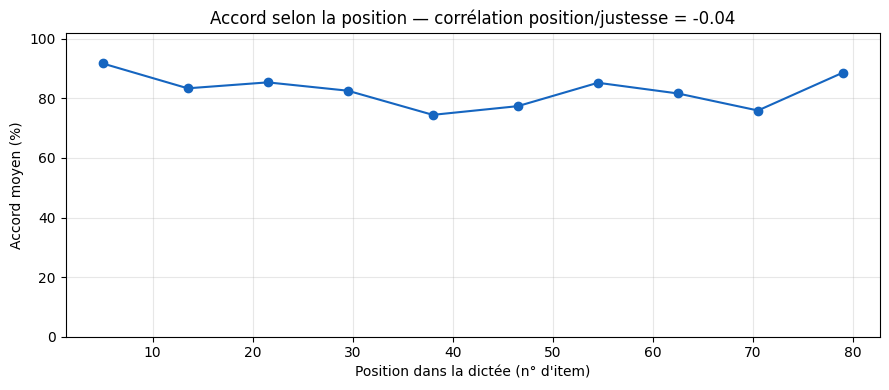

Corrélation -0.04 : pas d'effet de position évident à l'échelle globale.


In [13]:
corr = position_accuracy_correlation(df, ordered_ids)
tab_pos = accuracy_by_position(df, ordered_ids, n_bins=10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tab_pos["position_moy"], tab_pos["accord"] * 100, "-o", color="#1565c0")
ax.set_xlabel("Position dans la dictée (n° d'item)")
ax.set_ylabel("Accord moyen (%)")
ax.set_ylim(0, 102)
ax.grid(alpha=0.3)
ax.set_title(f"Accord selon la position — corrélation position/justesse = {corr:.2f}")
plt.tight_layout()
plt.show()

if corr < -0.15:
    print(f"⚠ Corrélation négative marquée ({corr:.2f}) : forte suspicion de décalage propagé.")
else:
    print(f"Corrélation {corr:.2f} : pas d'effet de position évident à l'échelle globale.")

## 2. Désaccords groupés ou isolés ?

Des erreurs **isolées** dispersées = vraies erreurs de codage ponctuelles.
Une **longue séquence consécutive** de désaccords = signature d'un décalage (tout
ce qui suit un oubli est faux jusqu'à un éventuel recalage).

,n_desaccords,plus_longue_sequence,position_debut_sequence
copy_id,,,
dictee_2015_0011.png,12,8,22
dictee_2015_0062.png,15,7,40
dictee_2015_0049.png,18,6,14
dictee_2015_0063.png,25,6,47
dictee_2015_0056.png,22,5,67
dictee_2015_0010.png,24,5,39
dictee_2015_0082.png,16,5,42
dictee_2015_0065.png,12,4,32
dictee_2015_0067.png,18,4,39


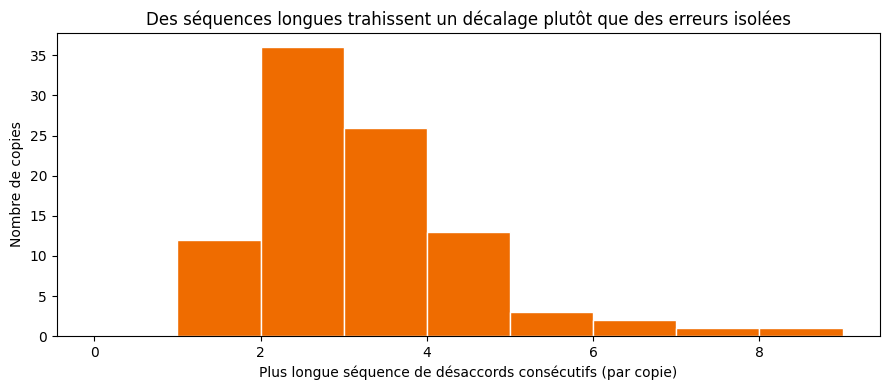

7 copie(s) avec une séquence ≥ 5 désaccords consécutifs (à inspecter en priorité).


In [14]:
runs = longest_disagreement_run(df, ordered_ids)
display(runs.head(10))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(runs["plus_longue_sequence"], bins=range(0, int(runs["plus_longue_sequence"].max()) + 2),
        color="#ef6c00", edgecolor="white")
ax.set_xlabel("Plus longue séquence de désaccords consécutifs (par copie)")
ax.set_ylabel("Nombre de copies")
ax.set_title("Des séquences longues trahissent un décalage plutôt que des erreurs isolées")
plt.tight_layout()
plt.show()

suspectes = runs[runs["plus_longue_sequence"] >= 5]
print(f"{len(suspectes)} copie(s) avec une séquence ≥ 5 désaccords consécutifs (à inspecter en priorité).")

## 3. Chute d'accord 1re moitié → 2de moitié, par copie

Isole les copies où le modèle commence bien puis décroche — typiquement quand un
oubli ou une difficulté survient en cours de copie.

In [15]:
eff = per_copy_position_effect(df, ordered_ids)
display(eff.head(10).style.format({"accord_moitie1": "{:.0%}", "accord_moitie2": "{:.0%}", "chute": "{:+.0%}"}))

,accord_moitie1,accord_moitie2,chute
copy_id,,,
dictee_2015_0021.png,100%,79%,+21%
dictee_2015_0032.png,93%,71%,+21%
dictee_2015_0071.png,85%,64%,+21%
dictee_2015_0057.png,83%,62%,+21%
dictee_2015_0077.png,95%,79%,+17%
dictee_2015_0005.png,90%,74%,+16%
dictee_2015_0083.png,73%,57%,+16%
dictee_2015_0009.png,71%,55%,+16%
dictee_2015_0073.png,93%,79%,+14%


## 4. Erreurs sur-confiantes

Les prédictions fausses annoncées avec une confiance élevée sont les plus
dangereuses : le renvoi humain ne les rattrape pas. Beaucoup de tels cas = confiance
inexploitable (cohérent avec un ECE élevé constaté dans l'analyse principale).

In [16]:
surconf = overconfident_errors(df, seuil_confiance=0.9)
surconf["mot"] = surconf["item_id"].map(id_to_mot)
n_faux = (df["y_true"] != df["y_pred"]).sum()
print(f"{len(surconf)} erreurs sur-confiantes (conf ≥ 0,9) sur {n_faux} erreurs totales "
      f"= {len(surconf)/max(n_faux,1):.0%} des erreurs passent sous le radar.")
display(surconf[["copy_id", "mot", "y_true", "y_pred", "confidence"]].head(15))

1342 erreurs sur-confiantes (conf ≥ 0,9) sur 1348 erreurs totales = 100% des erreurs passent sous le radar.


,copy_id,mot,y_true,y_pred,confidence
0,dictee_2015_0100.png,à,1,9,1.0
1,dictee_2015_0001.png,leurs,1,9,1.0
2,dictee_2015_0001.png,rentrés,1,9,1.0
3,dictee_2015_0001.png,perdus,1,9,1.0
4,dictee_2015_0001.png,pas,1,9,1.0
5,dictee_2015_0001.png,encore,1,9,1.0
6,dictee_2015_0001.png,retrouvé,9,1,1.0
7,dictee_2015_0001.png,nous,1,9,1.0
8,dictee_2015_0001.png,les,1,9,1.0
9,dictee_2015_0001.png,maison,1,9,1.0


## 5. Démonstration : un mot oublié décale-t-il l'évaluation ?

Test contrôlé. On part d'un codage parfait (le modèle = l'expert) sur une copie
réelle, puis on simule un modèle qui ne gère pas un mot omis et décale tout d'un cran
à partir de la position de l'oubli. On mesure l'effondrement de l'accord selon
**où** survient l'oubli. C'est la preuve de concept du mécanisme suspecté.

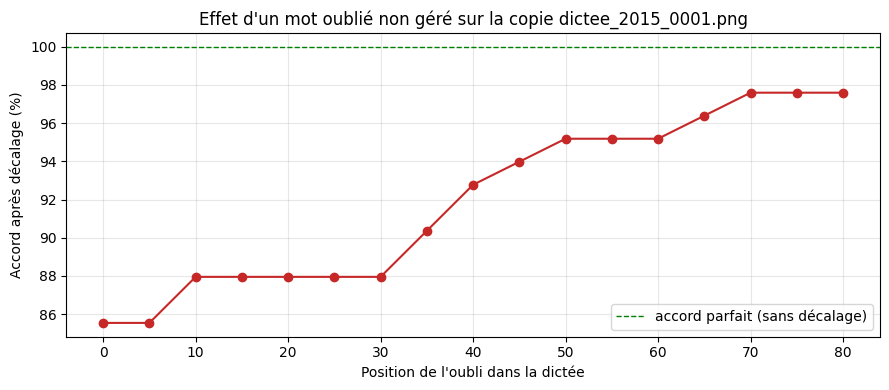

Lecture : plus l'oubli est précoce, plus l'accord s'effondre — car tous les
items suivants sont décalés. Un modèle robuste doit détecter l'absence (code 0)
sans décaler les items suivants.


In [17]:
# Codes experts d'une copie réelle (la première disponible)
premiere = df["copy_id"].iloc[0]
codes_expert = (
    df[df["copy_id"] == premiere].set_index("item_id").loc[ordered_ids, "y_true"].tolist()
)

positions = list(range(0, len(codes_expert), 5))
accords = [simulate_word_omission_shift(codes_expert, p)["accord_avec_decalage"] for p in positions]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(positions, [a * 100 for a in accords], "-o", color="#c62828")
ax.axhline(100, color="green", ls="--", lw=1, label="accord parfait (sans décalage)")
ax.set_xlabel("Position de l'oubli dans la dictée")
ax.set_ylabel("Accord après décalage (%)")
ax.set_title(f"Effet d'un mot oublié non géré sur la copie {premiere}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Lecture : plus l'oubli est précoce, plus l'accord s'effondre — car tous les")
print("items suivants sont décalés. Un modèle robuste doit détecter l'absence (code 0)")
print("sans décaler les items suivants.")

## 6. Copies-types à inspecter visuellement

Quatre palmarès complémentaires, chacun éclairant un mécanisme d'erreur. Les copies
qui apparaissent dans plusieurs palmarès sont les plus instructives à ouvrir.

In [18]:
hot = disagreement_hotspots(df, ordered_ids, top=5)
for nom, tab in hot.items():
    print(f"\n=== {nom} ===")
    display(tab)

# Union des copies signalées : la liste à inspecter
a_inspecter = set()
for tab in hot.values():
    a_inspecter.update(tab.index.tolist())
a_inspecter = sorted(a_inspecter)
print(f"\n{len(a_inspecter)} copies-types à inspecter : {a_inspecter}")


=== pire_accord ===


,accord
copy_id,
dictee_2015_0009.png,0.626506
dictee_2015_0083.png,0.650602
dictee_2015_0100.png,0.674699
dictee_2015_0045.png,0.686747
dictee_2015_0066.png,0.698795



=== plus_longue_sequence ===


,n_desaccords,plus_longue_sequence,position_debut_sequence
copy_id,,,
dictee_2015_0011.png,12,8,22
dictee_2015_0062.png,15,7,40
dictee_2015_0049.png,18,6,14
dictee_2015_0063.png,25,6,47
dictee_2015_0056.png,22,5,67



=== plus_forte_chute ===


,accord_moitie1,accord_moitie2,chute
copy_id,,,
dictee_2015_0021.png,1.000000,0.785714,0.214286
dictee_2015_0032.png,0.926829,0.714286,0.212544
dictee_2015_0071.png,0.853659,0.642857,0.210801
dictee_2015_0057.png,0.829268,0.619048,0.210221
dictee_2015_0077.png,0.951220,0.785714,0.165505



=== sur_confiance ===


,n_erreurs_surconfiantes
copy_id,
dictee_2015_0009.png,31
dictee_2015_0083.png,29
dictee_2015_0100.png,27
dictee_2015_0045.png,26
dictee_2015_0066.png,25



15 copies-types à inspecter : ['dictee_2015_0009.png', 'dictee_2015_0011.png', 'dictee_2015_0021.png', 'dictee_2015_0032.png', 'dictee_2015_0045.png', 'dictee_2015_0049.png', 'dictee_2015_0056.png', 'dictee_2015_0057.png', 'dictee_2015_0062.png', 'dictee_2015_0063.png', 'dictee_2015_0066.png', 'dictee_2015_0071.png', 'dictee_2015_0077.png', 'dictee_2015_0083.png', 'dictee_2015_0100.png']


## 7. Interface de comparaison visuelle

Génère un fichier HTML autonome affichant, pour chaque copie sélectionnée :
l'image numérisée, la transcription du modèle, le codage expert et le codage modèle,
avec les désaccords surlignés. Ouvrir le fichier dans le navigateur.

⚠ **Données sensibles** : le HTML contient des images d'élèves. Ne pas le sortir
de l'environnement sécurisé ni le committer (il est écrit dans `data/`, ignoré par Git).

In [19]:
# Labels experts (depuis S3) pour la comparaison
expert_labels = load_labels(LABELS_CSV)

out = generate_comparison_report(
    copy_ids=a_inspecter,
    predictions_df=df,
    grid_items=grid.items,
    images_dir=IMAGES_DIR,
    expert_labels=expert_labels,
    output_path=BASE / f"data/processed/diagnostic_visuel_{RUN_NAME}.html",
    scheme=SCHEME,
)
print(f"Interface générée : {out}")
print("Ouvrir ce fichier dans le navigateur (clic droit → Open in browser dans VSCode).")

Interface générée : ../data/processed/diagnostic_visuel_dictee_gemma4_zeroshot.html
Ouvrir ce fichier dans le navigateur (clic droit → Open in browser dans VSCode).


## 8. Copies triées par taux de désaccord brut

Table complète des copies, de la plus problématique à la mieux codée. Sert à
repérer d'un coup d'œil les copies à inspecter et à exporter pour analyse.

In [20]:
from evaluation_dictee.evaluation.report import copies_by_disagreement

classement = copies_by_disagreement(df)
display(classement.head(20).style.format({
    "pct_desaccord": "{:.1f} %", "accord": "{:.1%}"}))
# Export CSV
classement.to_csv(BASE / f"data/processed/{RUN_NAME}_copies_par_desaccord.csv",
                  sep=";", decimal=",", encoding="utf-8-sig")

,n_items,n_desaccords,pct_desaccord,accord
copy_id,,,,
dictee_2015_0009.png,83,31,37.3 %,62.7%
dictee_2015_0083.png,83,29,34.9 %,65.1%
dictee_2015_0100.png,83,27,32.5 %,67.5%
dictee_2015_0045.png,83,26,31.3 %,68.7%
dictee_2015_0066.png,83,25,30.1 %,69.9%
dictee_2015_0063.png,83,25,30.1 %,69.9%
dictee_2015_0050.png,83,25,30.1 %,69.9%
dictee_2015_0052.png,83,24,28.9 %,71.1%
dictee_2015_0010.png,83,24,28.9 %,71.1%


## 9. Inspecter les N copies les plus en désaccord

Génère le HTML diagnostic des N pires copies (image + transcription + codage
expert + codage modèle + désaccords surlignés).

In [21]:
from evaluation_dictee.evaluation.visual_diff import report_worst_copies

N_PIRES = 10  # nombre de copies à inspecter

out_pires = report_worst_copies(
    predictions_df=df,
    grid_items=grid.items,
    images_dir=IMAGES_DIR,
    expert_labels=expert_labels,
    output_path=BASE / f"data/processed/pires_{N_PIRES}_copies_{RUN_NAME}.html",
    n=N_PIRES,
    scheme=SCHEME,
)
print(f"Généré : {out_pires}")

Généré : ../data/processed/pires_10_copies_dictee_gemma4_zeroshot.html


## 10. Inspecter une copie précise par son identifiant

Saisir un `copy_id` pour afficher cette copie au format diagnostic complet.

In [22]:
from evaluation_dictee.evaluation.visual_diff import report_single_copy

# ← Saisir ici l'identifiant de la copie à inspecter
COPY_ID = classement.index[0]  # par défaut : la pire copie

out_single = report_single_copy(
    copy_id=COPY_ID,
    predictions_df=df,
    grid_items=grid.items,
    images_dir=IMAGES_DIR,
    expert_labels=expert_labels,
    output_path=BASE / f"data/processed/copie_{COPY_ID.replace('.png','')}.html",
    scheme=SCHEME,
)
print(f"Généré : {out_single}")

Généré : ../data/processed/copie_dictee_2015_0009.html
